In [1]:
# Dataset citation: Open Sustainable Development Goals (OSDG) Community Dataset, version 2024-04-01, file osdg-community-data-v2024-04-01.csv supplied in this repository. The file identifies DOI, text, SDG label, positive/negative labels, and agreement; no full publication citation was included alongside the CSV.

In [ ]:
# Imports and simple EDA helpers
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_ROOT = Path("..")

def inspect_table(df, name, preview_columns=None):
    print(f"\n{name}: {len(df):,} rows x {len(df.columns):,} columns")
    cols = preview_columns or list(df.columns[:8])
    shown = df[cols]
    display(pd.DataFrame({"column": shown.columns, "dtype": [str(x) for x in shown.dtypes],
                          "missing": shown.isna().sum().values,
                          "missing_%": (shown.isna().mean().values * 100).round(2),
                          "unique": shown.astype(str).nunique(dropna=True).values}))
    print(f"Duplicate rows on shown columns: {shown.astype(str).duplicated().sum():,}")
    display(shown.head(5))

def plot_counts(counts, title, xlabel="Class", ylabel="Rows"):
    counts = counts.sort_index()
    display(counts.rename("count").to_frame())
    ax = counts.plot(kind="bar", figsize=(11, 4), color="#4472C4")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def text_stats(df, column):
    if column not in df.columns:
        return
    values = df[column].fillna("").astype(str)
    lengths = values.str.len()
    words = values.str.split().str.len()
    print(f"\nText field: {column}")
    display(pd.DataFrame({"characters": lengths.describe(), "words": words.describe()}))
    print("Empty text rows:", int(values.str.strip().eq("").sum()))

In [3]:
# Step 2. Load data
path = DATA_ROOT / "osdg-community-data/osdg-community-data-v2024-04-01.csv"
df = pd.read_csv(path, sep="\t", low_memory=False)

In [ ]:
# Table and missing values
inspect_table(df, "OSDG Community Dataset", ["doi", "text", "sdg", "labels_negative", "labels_positive", "agreement"])


OSDG Community Dataset: 43,025 rows x 7 columns


,column,dtype,missing,missing_%,unique
0,doi,object,0,0.0,8192
1,text,object,0,0.0,43025
2,sdg,int64,0,0.0,16
3,labels_negative,int64,0,0.0,33
4,labels_positive,int64,0,0.0,66
5,agreement,float64,0,0.0,163


Duplicate rows on shown columns: 0


,doi,text,sdg,labels_negative,labels_positive,agreement
0,10.6027/9789289342698-7-en,"From a gender perspective, Paulgaard points ou...",5,1,8,0.777778
1,10.18356/eca72908-en,Labour legislation regulates maximum working h...,11,2,1,0.333333
2,10.1787/9789264289062-4-en,The average figure also masks large difference...,3,1,8,0.777778
3,10.1787/3726edff-en,Applied research is directed “primarily toward...,9,3,6,0.333333
4,10.1787/5k9b7bn5qzvd-en,The extent to which they are akin to corruptio...,3,1,2,0.333333


,count
sdg,
1,2734
2,2457
3,2689
4,3740
5,4338
6,2815
7,3048
8,1509
9,2697


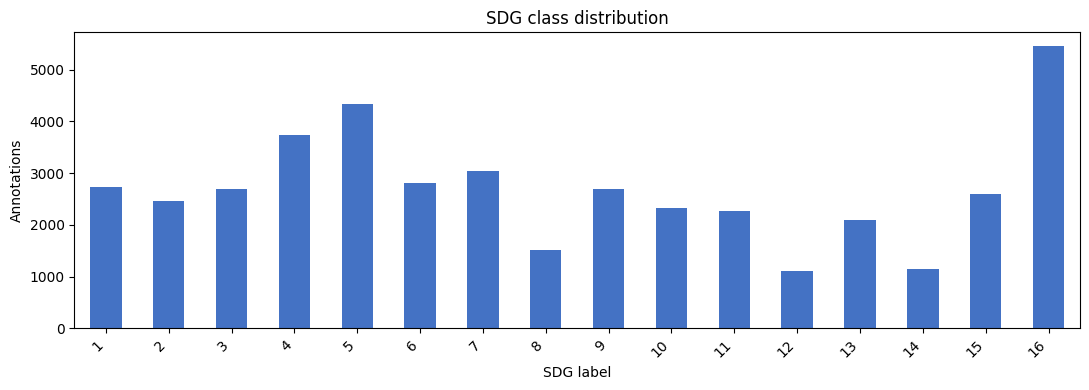

In [ ]:
# Class distribution
plot_counts(df["sdg"].value_counts(dropna=False), "SDG class distribution", "SDG label", "Annotations")

In [ ]:
# Agreement summary
display(df["agreement"].describe().to_frame("agreement"))

,agreement
count,43025.000000
mean,0.664557
std,0.317459
min,0.000000
25%,0.333333
50%,0.750000
75%,1.000000
max,1.000000


In [ ]:
# Positive and negative label counts
display(pd.DataFrame({"metric": ["positive labels", "negative labels"], "count": [df["labels_positive"].sum(), df["labels_negative"].sum()]}))

,metric,count
0,positive labels,237794
1,negative labels,72563
